In [1]:
#testing again


import moviepy
from moviepy import *
from moviepy.video import *
import copy
import accelerate
from pathlib import Path
import torch
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
import argparse
import os
import time
import pandas as pd
from PIL import Image
from transformers import (
    AutoProcessor,
    RTDetrForObjectDetection,
    VitPoseForPoseEstimation,
)
print(torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
index = 0
OUT_DIR = '../outputs'

while True:
    save =  'Trial - ' + str(index)
    outputPath = Path(f'{OUT_DIR}/{save}')
    if outputPath.is_dir():
        index += 1
        continue
    else:
        os.makedirs(f'{OUT_DIR}/{save}', exist_ok=False)
        OUT_DIR = OUT_DIR + f'/{save}'
        break


model_name = 'usyd-community/vitpose-plus-huge'



#save_name = 'Ivan'#args.input.split(os.path.sep)[-1].split('.')[0]
# Define codec and create VideoWriter object.

# Load detector.
person_image_processor = AutoProcessor.from_pretrained(
    'PekingU/rtdetr_r50vd_coco_o365'
)
person_model = RTDetrForObjectDetection.from_pretrained(
    'PekingU/rtdetr_r50vd_coco_o365', device_map=device
)
# Load ViTPose.
#print(f"Pose Model: {'../models/VitPose-s_RePoGen.pth'}")
image_processor = AutoProcessor.from_pretrained(model_name)
model = VitPoseForPoseEstimation.from_pretrained(pretrained_model_name_or_path=model_name, device_map=device)


#This is sadly chatted :(
# modelCustom = torch.load('../Models/VitPose-s_RePoGen.pth', device, weights_only=False)
# model.load_state_dict(modelCustom)
# image_processor.load_state_dict(modelCustom)
# image_processor.eval()
# model.eval()

c:\Users\danre\Documents\GitHub\SwimVisionProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [2]:
import math


edges = [
    (0, 1), (0, 2), (2, 4), (1, 3), (6, 8), (8, 10),
    (5, 7), (7, 9), (5, 11), (11, 13), (13, 15), (6, 12),
    (12, 14), (14, 16), (5, 6), (11, 12)
]

def lowToHigh(inputList):
    if (inputList[0] < inputList[1]):
        return inputList
    else:
        return (inputList[1], inputList[0])


def getBB(person_boxes):
    if person_boxes.any():
        box = person_boxes[0].tolist()
        box = [int(x) for x in box]
        return box
    else:
        return []

def drawBB(person_boxes, frame):
    box = getBB(person_boxes)
    if box:
        cv2.rectangle(frame, (box[0], box[1]), (box[0] + box[2], box[1] + box[3]), (0,0,255), 2)
    return frame


def detect_objects(image):
    """
    :param image: Image in PIL image format.
    Returns:
        person_boxes: Bboxes of persons in [x, y, w, h] format.
    """
    det_time_start = time.time()
    inputs = person_image_processor(
        images=image, return_tensors='pt'
    ).to(device)
    with torch.no_grad():
        outputs = person_model(**inputs)
    target_sizes = torch.tensor([(image.height, image.width)])
    
    results = person_image_processor.post_process_object_detection(
        outputs, target_sizes=target_sizes, threshold=0.3
    )
    det_time_end = time.time()
    det_fps = 1 / (det_time_end-det_time_start)
    
    # Extract the first result, as we can pass multiple images at a time.
    result = results[0]
    
    # In COCO dataset, humans labels have index 0.
    person_boxes_xyxy = result['boxes'][result['labels'] == 0]
    person_boxes_xyxy = person_boxes_xyxy.cpu().numpy()
    
    # Convert boxes from (x1, y1, x2, y2) to (x1, y1, w, h) format.
    person_boxes = person_boxes_xyxy.copy()
    person_boxes[:, 2] = person_boxes[:, 2] - person_boxes[:, 0]
    person_boxes[:, 3] = person_boxes[:, 3] - person_boxes[:, 1]
    if len(person_boxes) > 0:
        return np.array([person_boxes[0]]), det_fps
    else:
        return np.array([]), det_fps
    #return person_boxes, det_fps
def detect_pose(image, person_boxes):
    """
    :param image: Image in PIL image format.
    :param person_bboxes: Batched person boxes in [[x, y, w, h], ...] format.
    """
    pose_time_start = time.time()
    inputs = image_processor(
        image, boxes=[person_boxes], return_tensors='pt'
    ).to(device)
    
    dataset_index = torch.tensor([0], device=device) # must be a tensor of shape (batch_size,)
    if len(person_boxes) != 0:
        if 'plus' in model_name:
            with torch.no_grad():
                outputs = model(**inputs, dataset_index=dataset_index)
        else:
            with torch.no_grad():
                outputs = model(**inputs)
        
        pose_results = image_processor.post_process_pose_estimation(
            outputs, boxes=[person_boxes]
        )
    pose_time_end = time.time()
    pose_fps = 1 / (pose_time_end-pose_time_start)
    if len(person_boxes) == 0:
        return [], pose_fps
    image_pose_result = pose_results[0]
    #THIS IS A SANITY CHECK FOR THE MODEL

    realPoints = getKeypoints(image_pose_result)
    if (abs(slope(realPoints[5], realPoints[11]) > 2)): #More sanity check measures have to be made in the future if I don't get a better model
        image_pose_result = []
    return image_pose_result, pose_fps
def draw_keypoints(outputs, image):
    """
    :param outputs: Outputs from the keypoint detector.
    :param image: Image in PIL Image format.
    Returns:
        image: Annotated image Numpy array format.
    """
    image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    # the `outputs` is list which in-turn contains the dictionaries 
    for i, pose_result in enumerate(outputs):
        keypoints = pose_result['keypoints'].cpu().detach().numpy()
        # proceed to draw the lines if the confidence score is above 0.9
        keypoints = keypoints[:, :].reshape(-1, 2)
        # if keypoints.shape[0] != 0 and keypoints.shape[0] != 17:
        #     print(keypoints.shape[0]) 
        for p in range(keypoints.shape[0]):
            if p in [5, 7, 9, 11, 13, 15]:
                # draw the keypoints
                cv2.circle(image, (int(keypoints[p, 0]), int(keypoints[p, 1])), 
                            3, (0, 0, 255), thickness=-1, lineType=cv2.FILLED)
                # uncomment the following lines if you want to put keypoint number
                cv2.putText(image, f'{p}', (int(keypoints[p, 0]+10), int(keypoints[p, 1]-5)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
            for ie, e in enumerate(edges):
                if ((set([5, 7, 9, 11, 13, 15]) & set(e)) and not 12 in e and not 6 in e):
                    # get different colors for the edges
                    rgb = matplotlib.colors.hsv_to_rgb([
                        ie/float(len(edges)), 1.0, 1.0
                    ])
                    rgb = rgb*255
                    # join the keypoint pairs to draw the skeletal structure
                    cv2.line(image, (int(keypoints[e, 0][0]), int(keypoints[e, 1][0])),
                            (int(keypoints[e, 0][1]), int(keypoints[e, 1][1])),
                            tuple(rgb), 1, lineType=cv2.LINE_AA)
        break
    return image

body_edges = [(5, 9), (5, 11), (11, 13), (13, 15)] #THESE NEED TO BE LOWER NUMBER FIRST FOR ANGLE OPERATIONS TO WORK

def draw_keypoints_modded(keypoints, frame):
    for p in range(len(keypoints)):
        if p in [5, 9, 11, 13, 15]:
            # draw the keypoints
            cv2.circle(frame, (int(keypoints[p][0]), int(keypoints[p][1])), 
                        3, (0, 0, 255), thickness=-1, lineType=cv2.FILLED)
            # uncomment the following lines if you want to put keypoint number
            cv2.putText(frame, f'{p}', (int(keypoints[p][0]+10), int(keypoints[p][1]-5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
        for ie, e in enumerate(body_edges):
            #if ((set([5, 7, 9, 11, 13, 15]) & set(e)) and not 12 in e and not 6 in e):
                # get different colors for the edges
            rgb = matplotlib.colors.hsv_to_rgb([
                ie/float(len(edges)), 1.0, 1.0
            ])
            rgb = rgb*255
            # join the keypoint pairs to draw the skeletal structure
            cv2.line(frame, (int(keypoints[e[0]][0]), int(keypoints[e[0]][1])),
                    (int(keypoints[e[1]][0]), int(keypoints[e[1]][1])),
                    tuple(rgb), 1, lineType=cv2.LINE_AA)
    return frame




# def drawPersonBoxes(frame, boxes):
#     print(boxes)
#     for box in boxes:
#         cv2.rectangle(frame, (box[0], box[1]), (box[0] + box[2], box[1] + box[3]), (0,0,255), 2)
#     return frame

#Whole skeleton
# body_edges = [(6, 8), (8, 10),
#     (5, 7), (7, 9), (5, 11), (11, 13), (6, 12), (13, 15),
#     (12, 14), (14, 16), (5, 6), (11, 12)]

#Underwaters from left only



#https://stackoverflow.com/questions/14066933/direct-way-of-computing-the-clockwise-angle-between-two-vectors
# [left, vertex, right]
# Format needs to be this way because it calculates counterclockwise angle, not minimum angle
#angles1 =[[11, 5, 9], [13, 11, 5], [11, 13, 15]] 


angles =[[9, 5, 11], [5, 11, 13], [15, 13, 11]] 

def getAngles(points):
    angleList = []
    if points:
        for i in range(len(angles)):
            # print(points[angles[i][0]])
            # print(points[angles[i][1]])
            # print(points[angles[i][2]])

            x1 = points[angles[i][0]][0] - points[angles[i][1]][0]
            y1 = points[angles[i][0]][1] - points[angles[i][1]][1]
            x2 = points[angles[i][2]][0] - points[angles[i][1]][0]
            y2 = points[angles[i][2]][1] - points[angles[i][1]][1]
            # print(f'{x1}, {y1}    {x2}, {y2}')
            pointCombo = [[x1, y1], [x2, y2]]
            # print(pointCombo)
            # print(calcAngle(pointCombo))
            angleList.append(calcAngle(pointCombo))
    return angleList


def calcAngle(pointSet):
    p1, p2 = pointSet
    dot = (p1[0] * p2[0]) + (p1[1] * p2[1])
    det = (p1[0] * p2[1]) - (p1[1] * p2[0]) 
    rawAngle = math.atan2(-det, -dot) + math.pi 
    return round(math.degrees(rawAngle),2)

print(calcAngle([[-172, 29],[163, -34]]))

print(calcAngle([[0.7, -.7], [-0.7, -0.7]]))


samplePoints = [(12, -34), #0
(-8, 41), #1
(25, 25), #2
(-47, -10), #3
(3, 19), #4
(33, -4), #5
(-21, -39), #6
(45, 12), #7
(-15, 28), #8
(0, -48), #9
(37, 37), #10
(39, -55), #11
(18, -22), #12
(-1, -1), #13
(40, -40), #14
(-35, 15), #15
(10, 48)] #16

print(getAngles(samplePoints))





def drawAngles(frame, angleSet, points):
    if points:
        #points = switchOpenCVNormal( image, points)
        # for point in points:
        #     print(point)
        for i in range(len(angleSet)):
            leftIndex = angles[i][2]
            vertexIndex = angles[i][1]
            rightIndex = angles[i][0]

            leftPoint = points[leftIndex]
            vertexPoint = points[vertexIndex]
            rightPoint = points[rightIndex]

            normalizedLeftPoint = [leftPoint[0]- vertexPoint[0], leftPoint[1]-vertexPoint[1]]
            normalizedRightPoint = [rightPoint[0]- vertexPoint[0], rightPoint[1]-vertexPoint[1]]
            extraPointSet = [[1,0], normalizedLeftPoint]
            textAngle = (angleSet[i]/2) + calcAngle(extraPointSet)
            ellipseStartAngle = calcAngle(extraPointSet)
            ellipseEndAngle = calcAngle(extraPointSet) + angleSet[i] 

            cv2.ellipse(frame, (vertexPoint[0], vertexPoint[1]), (30, 30), 0, ellipseStartAngle, ellipseEndAngle, (0,0,255), 2)

            # print(f"Three points: {leftPoint}, {vertexPoint}, {rightPoint}")
            # print(f"Initial Angle: {angleSet[i]}")
            # print(f"Absolute Angle: {absoluteAngle}")

            drawPoint = [vertexPoint[0] + math.cos(math.radians(textAngle))*70 -20, vertexPoint[1] + math.sin(math.radians(textAngle))*70]

            cv2.putText(frame, f'{round(angleSet[i], 2)}', (int(drawPoint[0]), int(drawPoint[1])), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (240, 19, 255), 2) # I converted to left-hand coordinates here
    return frame



def drawAngleDiffs(frame, angleSet, diffAngleSet, points):
    if points and diffAngleSet:
        #points = switchOpenCVNormal( image, points)
        # for point in points:
        #     print(point)

        for i in range(len(angleSet)):
            leftIndex = angles[i][2]
            vertexIndex = angles[i][1]
            rightIndex = angles[i][0]

            leftPoint = points[leftIndex]
            vertexPoint = points[vertexIndex]
            rightPoint = points[rightIndex]

            normalizedLeftPoint = [leftPoint[0]- vertexPoint[0], leftPoint[1]-vertexPoint[1]]
            normalizedRightPoint = [rightPoint[0]- vertexPoint[0], rightPoint[1]-vertexPoint[1]]
            extraPointSet = [[1,0], normalizedLeftPoint]
            textAngle = (angleSet[i]/2) + calcAngle(extraPointSet)
            ellipseStartAngle = calcAngle(extraPointSet)
            ellipseEndAngle = calcAngle(extraPointSet) + angleSet[i] 

            cv2.ellipse(frame, (vertexPoint[0], vertexPoint[1]), (30, 30), 0, ellipseStartAngle, ellipseEndAngle, (0,0,255), 2)

            # print(f"Three points: {leftPoint}, {vertexPoint}, {rightPoint}")
            # print(f"Initial Angle: {angleSet[i]}")
            # print(f"Absolute Angle: {absoluteAngle}")
            yOffset = 0
            
            anglePoint = [vertexPoint[0] + math.cos(math.radians(textAngle))*70 -20, vertexPoint[1] + math.sin(math.radians(textAngle))*70]
            if (math.sin(math.radians(textAngle)) > 0):
                yOffset = 30
            else:
                yOffset = -30
            cv2.putText(frame, f'{round(angleSet[i], 2)}', (int(anglePoint[0]), int(anglePoint[1])), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (240, 19, 255), 2)
            if (diffAngleSet[i] < 0):
                cv2.putText(frame, f'({round(diffAngleSet[i], 2)})', (int(anglePoint[0])+10, int(anglePoint[1]) + yOffset), cv2.FONT_HERSHEY_SIMPLEX, 0.59, (23, 122, 5), 2)
            else:
                cv2.putText(frame, f'({round(diffAngleSet[i], 2)})', (int(anglePoint[0])+10, int(anglePoint[1]) + yOffset), cv2.FONT_HERSHEY_SIMPLEX, 0.59, (0, 0, 255), 2)
    return frame


pointOfFixation = 17

def cacheOffsets(points):
    xDistance = getBodyWidth(points)
    leftDistance = abs(xDistance- abs(points[15][0] - points[pointOfFixation][0]))
    rightDistance = abs(xDistance - abs(points[pointOfFixation][0]-points[9][0]))
    return [[leftDistance, rightDistance], [int(xDistance*.3), int(xDistance*.3)]]

def distance(point1, point2):
    return round(math.sqrt((math.pow(point1[0] - point2[0], 2) + math.pow(point1[1]- point2[1], 2))))

print(distance([1, 3], [7, 6]))

def getBodyWidth(points):
    sum = 0
    for pair in body_edges:
        sum += (distance(points[pair[0]], points[pair[1]]))
    return sum

def cropImage(frame, box, frameHeight, frameWidth):
    coords = [box[0], box[1], box[0] + box[2], box[1] + box[3]]
    buffer = 50
    #buffer = int(offsets[1][0] * 1.2)

    # lowX = points[pointOfFixation][0] - offsets[0][0]
    # highX = points[pointOfFixation][0] + offsets[0][1]
    # lowY = points[pointOfFixation][1] - offsets[1][0]
    # highY = points[pointOfFixation][1] + offsets[1][1]

    lowX = coords[0] - buffer
    highX = coords[2] + buffer
    lowY = coords[1] - buffer
    highY = coords[3] + buffer

    origin = (max(lowX, 0), max(lowY, 0))
    terminal = (min(highX, frameWidth), min(highY, frameHeight))

    points = [origin, terminal]
    croppedImage = frame[origin[1]:terminal[1], origin[0]: terminal[0]]
    croppedImage = cv2.resize(croppedImage, (frameWidth, frameHeight), interpolation=cv2.INTER_CUBIC)
    return croppedImage
        


def getKeypoints(outputs):
    out = []
    if outputs:
        keypoints = outputs[0]['keypoints'].cpu().detach().numpy()
        keypoints = keypoints[:, :].reshape(-1, 2)
        for p in range(keypoints.shape[0]):
            out.append([int(keypoints[p, 0]), int(keypoints[p, 1])])
        out.append(getAverageCoord(out[5], out[11]))
    return out

def drawSlopes(image, slopes, points):
    if slopes and points:
        for i, edge in enumerate(body_edges):
            average = getAverageCoord(points[edge[0]], points[edge[1]])
            cv2.putText(image, f'{round(slopes[i], 2)}', (average[0] -10, average[1]),
                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)           
    return image



def getSlopes(outputs, image, points):
    slopes = []
    if outputs and points:
        for i, edge in enumerate(body_edges):
            slopes.append(slope(points[edge[0]], points[edge[1]]))
    return slopes


def switchOpenCVNormal(image, kps):
    newkps = copy.deepcopy(kps)
    #print(newkps == kps)
    width, height = image.size
    for i in range(len(newkps)):
        newkps[i][1] = height - newkps[i][1]
    return newkps

def getAverageCoord(coord1, coord2):
    return [int((coord1[0] + coord2[0])/2), int((coord1[1] + coord2[1])/2)]

def slope(coord1, coord2):
    if coord1[0] - coord2[0] != 0:
        return ((coord1[1] - coord2[1]) / (coord1[0] - coord2[0])) 
    else:
        return 100 #Arbitrarily high slope


177.79
270.0
[43.58, 29.82, 151.73]
7


In [3]:

targetFPS = 30

def processVideo(videoName, flipNeeded):
    os.makedirs(f'{OUT_DIR}/{videoName}', exist_ok=False)
    inputPath = '../Data/' + videoName + '.mp4'
    cap = cv2.VideoCapture(inputPath)
    frame_width = int(cap.get(3))
    #print(frame_width)
    frame_height = int(cap.get(4))
    #print(frame_height)
    video_fps = round(cap.get(5)) 
    out = cv2.VideoWriter(
        f'{OUT_DIR}/{videoName}/Processed.mkv', 
        cv2.CAP_FFMPEG,
        cv2.VideoWriter_fourcc(*"FFV1"), 
        targetFPS, 
        (1920, 1080), 
    )
    if not cap.isOpened():
        print("Not opening in processing")
        
    framesNeeded = 0
    while cap.isOpened():
        res, frame = cap.read()
        if res:
            if flipNeeded:
                frame = cv2.flip(frame, 1)
            if frame_width != 1920 or frame_height != 1080:
                frame = cv2.resize(frame, (1920, 1080), interpolation=cv2.INTER_LANCZOS4)
            framesNeeded += (targetFPS/video_fps)
            #print(framesNeeded)
            cv2.imshow("Processing", frame)
            if (framesNeeded % 1 == 0):
                for j in range(int(framesNeeded)):
                    #print("Writing frame")
                    out.write(frame)
                framesNeeded = 0
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
        else:
            break
    cap.release()
    cv2.destroyAllWindows()
    out.release()



def flipNeededAndOffsets(videoName):
    inputPath = '../Data/' + videoName + '.mp4'
    cap = cv2.VideoCapture(inputPath)
    vidLength = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_width = int(cap.get(3))
    frame_height = int(cap.get(4))
    if not cap.isOpened():
        print("Not opening")
    curFrame = int(vidLength/2)
    output = False
    offsets = [[10000, 10000], [10000, 10000]]
    while True:
        cap.set(cv2.CAP_PROP_POS_FRAMES, curFrame)
        res, frame = cap.read()
        if res:
            #cv2.imshow('Frame', frame)
            if frame_width != 1920 or frame_height != 1080:
                frame = cv2.resize(frame, (1920, 1080), interpolation=cv2.INTER_LANCZOS4)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image = Image.fromarray(frame_rgb)
            bboxes, det_fps = detect_objects(image=image)
            image_pose_result, pose_fps = detect_pose(image=image, person_boxes=bboxes)
            kps = getKeypoints(image_pose_result)
            normalkps = switchOpenCVNormal(image, kps)
            if normalkps:
                output = normalkps[5][0] > normalkps[11][0]
                offsets = cacheOffsets(kps)
                break
        curFrame = curFrame+1
        if curFrame == vidLength-1:
            break
    cap.release()
    return [output, offsets]
            
    





def getMainPointsBBAndAngles(videoName):
    inputPath = f'{OUT_DIR}/{videoName}/Processed.mkv'
    cap = cv2.VideoCapture(inputPath)

    masterAngleList = []
    masterPointList = []
    masterBBList = []

    # offsets = [[2000, 2000], [2000, 2000]]
    # cachedOffsets = False
    if not cap.isOpened():
        print("Not opening")
        
    while cap.isOpened():
        ret, frame = cap.read()
        if ret:  
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image = Image.fromarray(frame_rgb)
            bboxes, det_fps = detect_objects(image=image)
            bb = getBB(bboxes)
            image_pose_result, pose_fps = detect_pose(image=image, person_boxes=bboxes)
            
            kps = getKeypoints(image_pose_result)
            normalkps = switchOpenCVNormal(image, kps)
            angle = getAngles(normalkps)
            masterAngleList.append(angle)
            masterPointList.append(normalkps)
            masterBBList.append(bb)
            # Press `q` to exit
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
        else:
            break
    cap.release()

    return [masterPointList, masterBBList, masterAngleList]



 # Release VideoCapture().

# Close all frames and video windows.
def findFirstFrame(angles):
    for i in range(len(angles)):
        if (angles[i]):
            if (angles[i][1] > 155 and angles[i][2]<145):
                return i
    return len(angles) -1 


In [4]:
# print(masterSlopeList)
# print(len(masterSlopeList))
# print(frame_count)

In [5]:


targetAngleID = 2

def findSmallest(angleList, initial):
    if angleList[initial]:
        lastAngle = angleList[initial][targetAngleID]
    for i in range (initial, len(angleList)):
        print(f"CHECKING FRAME {i}")
        if angleList[i]:
            curAngle = angleList[i][targetAngleID]
            print(curAngle)
            if (curAngle - lastAngle > 1):
                return i 
            lastAngle = curAngle
            end = i
    return end-1

def findLargest(angleList, initial):
    if angleList[initial]:
        lastAngle = angleList[initial][targetAngleID]
    largestFrame = initial
    for i in range (initial, len(angleList)):
        print(f"CHECKING FRAME {i}")
        if angleList[i]:
            curAngle = angleList[i][targetAngleID]
            print(curAngle)
            if (curAngle >= angleList[largestFrame][targetAngleID]):
                largestFrame = i
                print(f"New largest frame: {i}")
            if (lastAngle - curAngle > 5):
                return [i, largestFrame] 
            lastAngle = curAngle
            end = i
    return [end-1, end-1]


def getKickFrames(angleList):
    kickFrames = []
    start = findFirstFrame(angleList)
    print(f"STARTING FRAME: {start}")
    i = 0
    final = -1
    while True:
        if i == 0:
            initial = findSmallest(angleList, start) -1
            print(initial)
        else:
            initial = start
        middle = findLargest(angleList, initial)
        print(middle)
        final = findSmallest(angleList, middle[0])
        print(f'{[initial, middle, final-1]}')
        if initial != final-1 and angleList[final][2] < 155: #Rule 2 that may be needed: middle != final-1 
            kickFrames.append([initial, middle[1], final-1])
        else:
            break 
        start = final-1 
        i = i+1
    return kickFrames

    
def getClipLists(mainPointList, mainBBList, mainAngleList, kickFrames):
    outputPoints = []
    outputBB = []
    outputAngles = []
    for frameCombo in kickFrames:
        pointList = []
        bbList = []
        angleList = []
        for i in range(frameCombo[0], frameCombo[2]):
            angleList.append(mainAngleList[i])
            bbList.append(mainBBList[i])
            pointList.append(mainPointList[i])
        outputAngles.append(angleList)
        outputBB.append(bbList)
        outputPoints.append(pointList)
    return [outputPoints, outputBB, outputAngles]

def stretchOrCompressList(initial, target, usableKicks):
    normalizedList = []
    for i in range(usableKicks):
        normalizedClip = []
        currentLength = len(initial[i])
        targetLength = len(target[i])
        if targetLength - currentLength == 0:
            #interval = 0
            normalizedClip.append(initial[i])
            continue
        else:
            interval = currentLength / (targetLength - currentLength)
        counter = interval
        for j in range(1, currentLength+1):
            print(f'Count: {counter}, Rounded: {round(counter)}, frameCount: {j}, interval: {interval}, ')
            if (round(counter) == j):
                normalizedClip.append(initial[i][j-1])
                normalizedClip.append(initial[i][j-1])
                print(f"Frame {j}: double frame")
                counter += interval
            elif (-1*round(counter) == j):
                print(f"Frame {j}: skipped frame")
                counter += interval
            else:
                normalizedClip.append(initial[i][j-1])
                print(f"Frame {j}: normal frame")
        normalizedList.append(normalizedClip)
    return normalizedList


def getComparedAngles(learnerAngles, expertAngles, kicks):
    masterList = []
    #Starting the clip access phase
    for k in range(kicks):
        diffAnglesList = []
        for i in range(len(learnerAngles[k])):
            miniDiffsList = []
            if learnerAngles[k][i] and expertAngles[k][i]:
                for j in range(len(learnerAngles[k][i])):
                    diff = learnerAngles[k][i][j] - expertAngles[k][i][j]
                    miniDiffsList.append(round(diff,2))
            diffAnglesList.append(miniDiffsList)
        masterList.append(diffAnglesList)
    return masterList


        
def createDiffVideos(learnersVid, originalClipPointList, originalClipBBList, originalClipAngleList, normalizedClipPointList, angleDiffList, usableKicks, offsets, kickFrames):
    cap = cv2.VideoCapture(f'{OUT_DIR}/{learnersVid}/Processed.mkv')
    frame_width = int(cap.get(3))
    frame_height = int(cap.get(4))
    video_fps = int(cap.get(5))
    os.makedirs(f'{OUT_DIR}/{learnersVid}/Clips')
    for i in range(usableKicks):
        
        out2 = cv2.VideoWriter(
            f'{OUT_DIR}/{learnersVid}/Clips/{i}NA.mp4', 
            #cv2.CAP_FFMPEG,
            cv2.VideoWriter_fourcc(*"avc1"),
            video_fps, 
            (frame_width, frame_height), 
        )
        out1 = cv2.VideoWriter(
            f'{OUT_DIR}/{learnersVid}/Clips/{i}A.mp4', 
            #cv2.CAP_FFMPEG,
            cv2.VideoWriter_fourcc(*"avc1"),
            video_fps, 
            (frame_width, frame_height), 
        )

        currentLength = len(originalClipPointList[i])
        targetLength = len(normalizedClipPointList[i]) 

        if targetLength - currentLength == 0:
            interval = 0
        else:
            interval = currentLength / (targetLength - currentLength)

        count = interval

        frame_count = 0
        cachedBB = [0,0] * 4

        if not cap.isOpened():
            print("Not opening")
        print(f"Angle Diff list?: {angleDiffList[i]}")
        for j in range(kickFrames[i][0], kickFrames[i][2]):

            cap.set(cv2.CAP_PROP_POS_FRAMES, j)
            ret, frame = cap.read()
            if ret:
                normalkps = originalClipPointList[i][frame_count]
                bb = originalClipBBList[i][frame_count]
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                image = Image.fromarray(frame_rgb)
                kps = switchOpenCVNormal(image, normalkps)
                frame = draw_keypoints_modded(kps, frame)
                angle = originalClipAngleList[i][frame_count]
                result = drawAngleDiffs(frame, angle, angleDiffList[i][frame_count], kps)
                if bb:
                    cachedBB = bb
                result = cropImage(result, cachedBB, frame_height, frame_width)
                out1.write(result)
                frame_count += 1
                if interval == 0:
                    out2.write(result)
                    print(f"Frame {frame_count}: normal frame")
                else: 
                    print(f'Count: {count}, Rounded: {round(count)}, frameCount: {frame_count}, interval: {interval}, ')
                    if (round(count) == frame_count):
                        out2.write(result) 
                        out2.write(result)
                        print(f"Frame {frame_count}: double Frame")
                        count = count + interval
                    elif (-1*(round(count)) == frame_count):
                        print(f"Frame {frame_count}: frame Skipped")
                        count = count + interval
                    else:
                        print(f"Frame {frame_count}: normal frame")
                        out2.write(result)
                
                cv2.imshow('Prediction', result)
                # Press `q` to exit
                if cv2.waitKey(1) & 0xFF == ord('q'):
                    break
            else:
                break
        cv2.destroyAllWindows()
        out1.release()
        out2.release()
    cap.release()


 

Agenda for tmrw:

1. Throw the slope gathering into a method (done)
2. Make clip creation a method (done)
3. pick minimum amount of kicks and compare the first n kicks (done)
4. Create clips, make sure the learner clips are normalized to the expert's length (doing)
5. Calc difference every single slope between each frame of the normalized clips.  Store best and worse absolute diff + average for that frame
6. Create a list for each frame that records diff of each edge
7. Make a method to turn  diff list into summary list with 
 [average, [best joint, accuracy], [worst frame, accuracy]]
8. Make methods to extract this data to find overall superlatives (best frame, worst frame, worst joint of them all, best joint of them all)
9. Get accuracy for each kick and overall
10. If you really want splice the kick clips tg, get acc % differences for each joint every frame of recording, color grade them based on % diff, extend clip to like 10 seconds 

What is left:

1. Fill in gaps between kicks (done)
2. Make final display video (done)
3. Make rules that figure out when underwater starts + how many kicks there are (done)
4. Similarity report
5. Possible stretches given low angle for smth

In [6]:
#MainAngles3 = makeMainVideo("flipTurnHQ")

def makePreComparisonClip(vidName, kickFrames, mainPointList, mainBBList, mainAngleList, offsets):
    cap = cv2.VideoCapture(f'{OUT_DIR}/{vidName}/Processed.mkv')
    frame_width = int(cap.get(3))
    frame_height = int(cap.get(4))
    video_fps = int(cap.get(5))
    out = cv2.VideoWriter(
        f'{OUT_DIR}/{vidName}/Clips/PreDetectionClip.mp4', 
        #cv2.CAP_FFMPEG,
        cv2.VideoWriter_fourcc(*"avc1"), 
        video_fps, 
        (frame_width, frame_height), 
    )
    cachedBB = [0, 0] * 4
    for i in range(0, kickFrames[0][0]):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        res, frame = cap.read()
        if res:
            normalkps = mainPointList[i]
            bb = mainBBList[i]
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image = Image.fromarray(frame_rgb)
            kps = switchOpenCVNormal(image, normalkps)
            result = draw_keypoints_modded(kps, frame)
            angle = mainAngleList[i]
            result = drawAngles(result, angle, kps)
            if bb:
                cachedBB = bb
            result = cropImage(result, cachedBB, frame_height, frame_width)
            out.write(result)
    cap.release()
    out.release()

def makePostComparisonClip(vidName, kickFrames, usableKicks, mainPointList, mainBBList, mainAngleList, offsets):
    cap = cv2.VideoCapture(f'{OUT_DIR}/{vidName}/Processed.mkv')
    vidLength = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_width = int(cap.get(3))
    frame_height = int(cap.get(4))
    video_fps = int(cap.get(5))
    out = cv2.VideoWriter(
        f'{OUT_DIR}/{vidName}/Clips/PostDetectionClip.mp4', 
        #cv2.CAP_FFMPEG,
        cv2.VideoWriter_fourcc(*"avc1"),
        video_fps, 
        (frame_width, frame_height), 
    )
    cachedBB = [0, 0] * 4
    for i in range(kickFrames[usableKicks-1][2], vidLength):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        res, frame = cap.read()
        if res:
            normalkps = mainPointList[i]
            bb = mainBBList[i]
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image = Image.fromarray(frame_rgb)
            kps = switchOpenCVNormal(image, normalkps)
            result = draw_keypoints_modded(kps, frame)
            angle = mainAngleList[i]
            result = drawAngles(result, angle, kps)
            if bb:
                cachedBB = bb
            result = cropImage(result, cachedBB, frame_height, frame_width)
            out.write(result)
    cap.release()
    out.release()

def makeOutputVid1(vidName, kickFrames, kicks, mainPointList, mainBBList, mainAngleList, offsets):
    makePreComparisonClip(vidName, kickFrames, mainPointList, mainBBList, mainAngleList, offsets)
    cap = cv2.VideoCapture(f'{OUT_DIR}/{vidName}/Clips/PreDetectionClip.mp4')
    frame_width = int(cap.get(3))
    frame_height = int(cap.get(4))
    video_fps = int(cap.get(5))
    out = cv2.VideoWriter(
        f'{OUT_DIR}/{vidName}/FinalVideo1Normal.mp4', 
        cv2.VideoWriter_fourcc(*'avc1'), 
        video_fps, 
        (frame_width, frame_height), 
    )
    out1 = cv2.VideoWriter(
        f'{OUT_DIR}/{vidName}/FinalVideo1Slow.mp4', 
        cv2.VideoWriter_fourcc(*'avc1'), 
        video_fps, 
        (frame_width, frame_height), 
    )
    if not cap.isOpened():
            print("Not opening")
    while cap.isOpened():
        ret, frame = cap.read()
        if ret:
            #I can add annotations here
            out.write(frame)
            out1.write(frame)
            # Press `q` to exit
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
        else:
            break
    cap.release()
    del cap
    for i in range(kicks):
        cap = cv2.VideoCapture(f'{OUT_DIR}/{vidName}/Clips/{i}A.mp4')
        if not cap.isOpened():
            print("Not opening")
        while cap.isOpened():
            ret, frame = cap.read()
            if ret:
                #I can add annotations here
                out.write(frame)
                out1.write(frame)
                out1.write(frame)
                out1.write(frame)
                out1.write(frame)
                # Press `q` to exit
                if cv2.waitKey(1) & 0xFF == ord('q'):
                    break
            else:
                break
        cap.release()
        del cap
    makePostComparisonClip(vidName, kickFrames, kicks, mainPointList, mainBBList, mainAngleList, offsets)
    cap = cv2.VideoCapture(f'{OUT_DIR}/{vidName}/Clips/PostDetectionClip.mp4')
    if not cap.isOpened():
        print("Not opening")
    while cap.isOpened():
        ret, frame = cap.read()
        if ret:
            #I can add annotations here
            out.write(frame)
            out1.write(frame)
            # Press `q` to exit
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
        else:
            break
    cap.release()
    del cap
    out.release()
    out1.release()

def makeOutputVid2(learnerVid, kickFrames, usableKicks):
    print(kickFrames)
    cap = cv2.VideoCapture(f'{OUT_DIR}/{learnerVid}/FinalVideo1Normal.mp4')
    #vidLength = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_width = int(cap.get(3))
    frame_height = int(cap.get(4))
    video_fps = int(cap.get(5))
    out = cv2.VideoWriter(
        f'{OUT_DIR}/{learnerVid}/FinalVideo2.mp4', 
        cv2.VideoWriter_fourcc(*'avc1'), 
        video_fps, 
        (frame_width, frame_height), 
    )
    for i in range(usableKicks):
        #print(i)
        cap.set(cv2.CAP_PROP_POS_FRAMES, kickFrames[i][0])
        res, frame = cap.read()
        if res:
            cv2.putText(
                frame,
                f"Kick {i+1} High",
                (40, 80),
                fontFace=cv2.FONT_HERSHEY_SIMPLEX,
                fontScale=1.5,
                color=(0, 0, 255),
                thickness=2,
                lineType=cv2.LINE_AA,
            )
            for j in range(video_fps*3):
                out.write(frame)
                
        #print(kickFrames[i])
        cap.set(cv2.CAP_PROP_POS_FRAMES, kickFrames[i][1])
        res, frame = cap.read()
        if res:
            cv2.putText(
                frame,
                f"Kick {i+1} Low",
                (40, 80),
                fontFace=cv2.FONT_HERSHEY_SIMPLEX,
                fontScale=1.5,
                color=(0, 0, 255),
                thickness=2,
                lineType=cv2.LINE_AA,
            )
            for j in range(video_fps*3):
                out.write(frame)
    cap.release()
    out.release()


def synthesizeNormalizedLearnersClips(learnerVid, usableKicks):
    for i in range(usableKicks):
        cap = cv2.VideoCapture(f'{OUT_DIR}/{learnerVid}/Clips/{i}NA.mp4')
        if i == 0:
            frame_width = int(cap.get(3))
            frame_height = int(cap.get(4))
            video_fps = int(cap.get(5))
            out = cv2.VideoWriter(
                f'{OUT_DIR}/{learnerVid}/Clips/SynthesizedClips.mp4', 
                cv2.VideoWriter_fourcc(*'avc1'), 
                video_fps, 
                (frame_width, frame_height), 
            )
        if not cap.isOpened():
            print("Not opening")
        while cap.isOpened():
            ret, frame = cap.read()
            if ret:
                #I can add annotations here
                out.write(frame)
                # Press `q` to exit
                if cv2.waitKey(1) & 0xFF == ord('q'):
                    break
            else:
                break
        cap.release()
        del cap
    out.release()

def makeAnnotatedExpertClips(expertVid, mainExpertPoints, mainExpertBB, mainExpertAngles, kickFrames, offsets, usableKicks):
    os.makedirs(f'{OUT_DIR}/{expertVid}/Clips')
    for i in range(usableKicks):
        cap = cv2.VideoCapture(f'{OUT_DIR}/{expertVid}/Processed.mkv')
        frame_width = int(cap.get(3))
        frame_height = int(cap.get(4))
        video_fps = int(cap.get(5))
        out = cv2.VideoWriter(
            f'{OUT_DIR}/{expertVid}/Clips/{i}A.mp4', 
            #cv2.CAP_FFMPEG,
            cv2.VideoWriter_fourcc(*"avc1"),
            video_fps, 
            (frame_width, frame_height), 
        )
        cachedBB = [0,0] * 4
        for j in range(kickFrames[i][0], kickFrames[i][2]):
            cap.set(cv2.CAP_PROP_POS_FRAMES, j)
            ret, frame = cap.read()
            if ret:
                normalKps = mainExpertPoints[j]
                bb = mainExpertBB[j]
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                image = Image.fromarray(frame_rgb)
                kps = switchOpenCVNormal(image, normalKps)
                frame = draw_keypoints_modded(kps, frame)
                angle = mainExpertAngles[j]
                result = drawAngles(frame, angle, kps)
                if bb:
                    cachedBB = bb
                result = cropImage(result, cachedBB, frame_height, frame_width)
                out.write(result)
                # Press `q` to exit
                if cv2.waitKey(1) & 0xFF == ord('q'):
                    break
            else:
                break
        cap.release()
        out.release()


    


def synthesizeExpertsClips(expertVid, usableKicks):
    for i in range(usableKicks):
        cap = cv2.VideoCapture(f'{OUT_DIR}/{expertVid}/Clips/{i}A.mp4')
        if i == 0:
            frame_width = int(cap.get(3))
            frame_height = int(cap.get(4))
            video_fps = int(cap.get(5))
            out = cv2.VideoWriter(
                f'{OUT_DIR}/{expertVid}/Clips/SynthesizedClips.mp4', 
                cv2.VideoWriter_fourcc(*"avc1"),
                video_fps, 
                (frame_width, frame_height), 
            )
        if not cap.isOpened():
            print("Not opening")
        while cap.isOpened():
            ret, frame = cap.read()
            if ret:
                #I can add annotations here
                out.write(frame)
                # Press `q` to exit
                if cv2.waitKey(1) & 0xFF == ord('q'):
                    break
            else:
                break
        cap.release()
        del cap
    out.release()


def makeOutputVid3(expertVid, learnerVid, kickFrames2, usableKicks, mainExpertPoints, mainExpertBB, mainExpertAngles, offsets):
    synthesizeNormalizedLearnersClips(learnerVid, usableKicks)
    makeAnnotatedExpertClips(expertVid, mainExpertPoints, mainExpertBB, mainExpertAngles, kickFrames2, offsets, usableKicks)
    synthesizeExpertsClips(expertVid, usableKicks)

    learnerCap = cv2.VideoCapture(f'{OUT_DIR}/{learnerVid}/Clips/SynthesizedClips.mp4')
    expertCap = cv2.VideoCapture(f'{OUT_DIR}/{expertVid}/Clips/SynthesizedClips.mp4')

    frame_width = int(learnerCap.get(3))
    frame_height = int(learnerCap.get(4))
    video_fps = int(learnerCap.get(5))
    vidLength = int(learnerCap.get(cv2.CAP_PROP_FRAME_COUNT))

    out = cv2.VideoWriter(
            f'{OUT_DIR}/{learnerVid}/FinalVideo3Normal.mp4', 
            # #cv2.CAP_FFMPEG,
            cv2.VideoWriter_fourcc(*"mp4v"),
            video_fps, 
            (frame_width, frame_height), 
        )
    
    out2 = cv2.VideoWriter(
        f'{OUT_DIR}/{learnerVid}/FinalVideo3Slow.mp4', 
        cv2.VideoWriter_fourcc(*'mp4v'), 
        video_fps, 
        (frame_width, frame_height), 
    )

    if not learnerCap.isOpened() or not expertCap.isOpened():
        print("One of them isn't opening")
    
    for i in range(vidLength):
        learnerCap.set(cv2.CAP_PROP_POS_FRAMES, i)
        expertCap.set(cv2.CAP_PROP_POS_FRAMES, i)
        learnerRes, learnerFrame = learnerCap.read()
        expertRes, expertFrame = expertCap.read()
        if learnerRes and expertRes:
            outputImage = np.zeros((frame_height,frame_width,3), np.uint8)
            learnerFrame = cv2.resize(learnerFrame, (int(frame_width/2), int(frame_height/2)), interpolation=cv2.INTER_AREA)
            expertFrame = cv2.resize(expertFrame, (int(frame_width/2), int(frame_height/2)), interpolation=cv2.INTER_AREA)
            outputImage[0:int(frame_height/2), int(frame_width/4): int(frame_width*.75)] = learnerFrame
            outputImage[int(frame_height/2):int(frame_height), int(frame_width/4): int(frame_width*.75)] = expertFrame
            cv2.imshow("Merge", outputImage)
            out.write(outputImage)
            for i in range(4):
                out2.write(outputImage)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
        else:
            break
    expertCap.release()
    learnerCap.release()
    cv2.destroyAllWindows()
    out.release
    out2.release()
            


def makeOutputVid5(vidName):
    cap = cv2.VideoCapture(f'{OUT_DIR}/{vidName}/FinalVideo3.mp4')
    frame_width = int(cap.get(3))
    frame_height = int(cap.get(4))
    video_fps = int(cap.get(5))
    out = cv2.VideoWriter(
        f'{OUT_DIR}/{vidName}/FinalVideo5.mp4', 
        cv2.VideoWriter_fourcc(*'avc1'), 
        video_fps, 
        (frame_width, frame_height), 
    )
    if not cap.isOpened():
            print("Not opening")
    while cap.isOpened():
        ret, frame = cap.read()
        if ret:
            #I can add annotations here
            for i in range(10):
                out.write(frame)
            # Press `q` to exit
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
        else:
            break
    cap.release()
    out.release()

#Need to redo these for the app


# def getHighLowClipDifferenceData(clipAnglesLearner, learnerAngleDiffList, learnerKickFrames, usableKicks):
#     finalList = []
#     for i in range(usableKicks):
#         print(clipAnglesLearner[i])
#         print(learnerAngleDiffList[i])
#         high = [clipAnglesLearner[i][0], subtractElements(clipAnglesLearner[i][0], learnerAngleDiffList[i][0]), learnerAngleDiffList[i][0]]
#         low = [clipAnglesLearner[i][learnerKickFrames[i][1]-learnerKickFrames[i][0]], subtractElements(clipAnglesLearner[i][learnerKickFrames[i][1]-learnerKickFrames[i][0]], learnerAngleDiffList[i][learnerKickFrames[i][1]-learnerKickFrames[i][0]]), learnerAngleDiffList[i][learnerKickFrames[i][1]-learnerKickFrames[i][0]]]
#         list1 = []
#         list2 = []
#         for j in range(len(high)):
#             for k in range(len(high[j])):
#                 list1.append(high[j][k])
#                 list2.append(low[j][k])
#         finalList.append(list1)
#         finalList.append(list2)
#     return finalList





learnersVid = "learnerUnderwater"
expertVid = "expertUnderwater"   
        

# def completeProcess(learnersVid, expertsVid):
flipRequired1, offset1 = flipNeededAndOffsets(learnersVid)
flipRequired2, offset2 = flipNeededAndOffsets(expertVid)
processVideo(learnersVid, flipRequired1)
processVideo(expertVid, flipRequired2)

mainPointsLearner, mainBBLearner, mainAnglesLearner = getMainPointsBBAndAngles(learnersVid)
kickFrames1 = getKickFrames(mainAnglesLearner)
clipPointsLearner, clipBBLearner, clipAnglesLearner = getClipLists(mainPointsLearner, mainBBLearner, mainAnglesLearner, kickFrames1)

mainPointsExpert, mainBBExpert, mainAnglesExpert = getMainPointsBBAndAngles(expertVid)
kickFrames2 = getKickFrames(mainAnglesExpert)
clipPointsExpert, clipBBExpert, clipAnglesExpert = getClipLists(mainPointsExpert, mainBBExpert, mainAnglesExpert, kickFrames2)
print(f"MAIN ANGLES EXPERT {mainAnglesExpert}")

kicks = min(len(kickFrames1), len(kickFrames2))
print(f"KickFrames1: {kickFrames1}")
print(f"KickFrames2: {kickFrames2}")
normalizedLearnerPoints = stretchOrCompressList(clipPointsLearner, clipPointsExpert, kicks)
normalizedLearnerBB = stretchOrCompressList(clipBBLearner, clipBBExpert, kicks)
normalizedLearnerAngles = stretchOrCompressList(clipAnglesLearner, clipAnglesExpert, kicks)

# print("IMPORTANT STUFF")
# print(len(clipAnglesLearner[0]))
# print(len(clipAnglesExpert[0]))
# print(len(normalizedLearnerAngles[0]))


# print(normalizedLearnerAngles)
# print(clipAnglesExpert)
angleDiffList = getComparedAngles(normalizedLearnerAngles, clipAnglesExpert, kicks)
# print(angleDiffList)
# print(clipAnglesLearner)
learnerAngleDiffList = stretchOrCompressList(angleDiffList, clipAnglesLearner, kicks)

createDiffVideos(learnersVid, clipPointsLearner, clipBBLearner, clipAnglesLearner, normalizedLearnerPoints, learnerAngleDiffList, kicks, offset1, kickFrames1)

makeOutputVid1(learnersVid, kickFrames1, kicks, mainPointsLearner, mainBBLearner, mainAnglesLearner, offset1)
makeOutputVid2(learnersVid, kickFrames1, kicks)
makeOutputVid3(expertVid, learnersVid, kickFrames2, kicks, mainPointsExpert, mainBBExpert, mainAnglesExpert, offset2)





#completeProcess(learnerVid, expertVid)


STARTING FRAME: 0
CHECKING FRAME 0
136.66
CHECKING FRAME 1
119.85
CHECKING FRAME 2
102.55
CHECKING FRAME 3
101.79
CHECKING FRAME 4
116.2
3
CHECKING FRAME 3
101.79
New largest frame: 3
CHECKING FRAME 4
116.2
New largest frame: 4
CHECKING FRAME 5
138.44
New largest frame: 5
CHECKING FRAME 6
156.75
New largest frame: 6
CHECKING FRAME 7
CHECKING FRAME 8
183.24
New largest frame: 8
CHECKING FRAME 9
192.4
New largest frame: 9
CHECKING FRAME 10
190.73
CHECKING FRAME 11
189.36
CHECKING FRAME 12
189.63
CHECKING FRAME 13
CHECKING FRAME 14
186.51
CHECKING FRAME 15
181.75
CHECKING FRAME 16
171.41
[16, 9]
CHECKING FRAME 16
171.41
CHECKING FRAME 17
159.82
CHECKING FRAME 18
152.57
CHECKING FRAME 19
141.5
CHECKING FRAME 20
125.59
CHECKING FRAME 21
108.84
CHECKING FRAME 22
105.49
CHECKING FRAME 23
114.96
[3, [16, 9], 22]
CHECKING FRAME 22
105.49
New largest frame: 22
CHECKING FRAME 23
114.96
New largest frame: 23
CHECKING FRAME 24
132.2
New largest frame: 24
CHECKING FRAME 25
152.44
New largest frame: 

[[161.36, 164.27, 101.79], [165.08, 158.55, 116.2], [170.38, 155.25, 138.44], [174.12, 152.35, 156.75], [], [183.21, 158.46, 183.24], [187.83, 163.58, 192.4], [188.63, 167.29, 190.73], [195.6, 168.87, 189.36], [196.48, 177.38, 189.63], [], [191.01, 191.91, 186.51], [185.05, 199.22, 181.75], [178.44, 200.87, 171.41], [174.31, 199.92, 159.82], [168.04, 202.09, 152.57], [162.36, 200.76, 141.5], [162.2, 196.07, 125.59], [161.76, 187.18, 108.84]]
[[8.7, -3.3, -4.68], [10.1, -1.26, -2.46], [3.26, -2.58, -19.38], [3.26, -2.58, -19.38], [], [8.5, -1.42, 1.05], [8.15, -5.11, -2.54], [8.15, -5.11, -2.54], [14.4, -2.39, -5.69], [18.3, -3.05, -1.32], [18.3, -3.05, -1.32], [18.48, -1.94, 2.14], [15.83, 1.35, 2.99], [16.99, -3.1, 1.43], [16.99, -3.1, 1.43], [16.8, -2.55, 10.15], [13.46, -2.68, 7.94], [19.66, -4.02, 1.75], [19.66, -4.02, 1.75]]
[[165.57, 172.08, 105.49], [169.94, 160.78, 114.96], [173.91, 156.14, 132.2], [179.34, 156.12, 152.44], [181.51, 158.23, 167.72], [185.37, 161.87, 180.51], [1

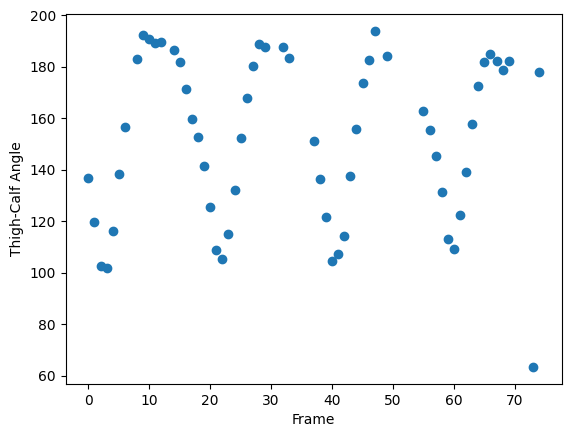

In [7]:
perfection = 5.0
prettyWell = 10.0
bad = 20.0

def subtractElements(list1, list2):
    outputList = []
    for i in range(len(list1)):
        outputList.append(round(list1[i] - list2[i], 2))
    return outputList



def showCalfAngleGraph(mainAngles):
    x = []
    y = []
    for i in range(len(mainAngles)):
        if (mainAngles[i]):
            x.append(i)
            y.append(mainAngles[i][2])

    plt.scatter(x, y)
    plt.xlabel("Frame")
    plt.ylabel("Thigh-Calf Angle")
    plt.show()



def printReport(highLowClipDifferences):
    print("\n------- REPORT -------\n")
    for i in range(len(highLowClipDifferences)):
        if (i % 2 == 0):
            print(f"Kick {i//2 + 1} High:\n")
        else:
            print(f"Kick {i//2 + 1} Low:\n")

        if (highLowClipDifferences[i][6] <= perfection and highLowClipDifferences[i][6] >= -perfection):
            print("Your arms are perfectly fine!")
        elif (highLowClipDifferences[i][6] > perfection and highLowClipDifferences[i][6] <= prettyWell):
            print("Pull your arms down a little!")
        elif (highLowClipDifferences[i][6] < -perfection and highLowClipDifferences[i][6] >= -prettyWell):
            print("Pull your arms up a little!")
        elif (highLowClipDifferences[i][6] > prettyWell and highLowClipDifferences[i][6] <= bad):
            print("Pull your arms down!")
        elif (highLowClipDifferences[i][6] < -prettyWell and highLowClipDifferences[i][6] >= -bad):
            print("Pull your arms up!")
        elif (highLowClipDifferences[i][6] > bad):
            print("Pull your arms down a lot!")
        elif (highLowClipDifferences[i][6] < -bad):
            print("Pull your arms up a lot!")
        
        if (highLowClipDifferences[i][7] <= perfection and highLowClipDifferences[i][7] >= -perfection):
            print("Your hips are perfectly fine!")
        elif (highLowClipDifferences[i][7] > perfection and highLowClipDifferences[i][7] <= prettyWell):
            print("Pull your hips up a little!")
        elif (highLowClipDifferences[i][7] < -perfection and highLowClipDifferences[i][7] >= -prettyWell):
            print("Pull your hips down a little!")
        elif (highLowClipDifferences[i][7] > prettyWell and highLowClipDifferences[i][7] <= bad):
            print("Pull your hips up!")
        elif (highLowClipDifferences[i][7] < -prettyWell and highLowClipDifferences[i][7] >= -bad):
            print("Pull your hips down!")
        elif (highLowClipDifferences[i][7] > bad):
            print("Pull your hips up a lot!")
        elif (highLowClipDifferences[i][7] < -bad):
            print("Pull your hips down a lot!")


        if (highLowClipDifferences[i][8] <= perfection and highLowClipDifferences[i][8] >= -perfection):
            print("Your legs are perfectly fine!")
        elif (highLowClipDifferences[i][8] > perfection and highLowClipDifferences[i][8] <= prettyWell):
            print("Pull your legs in a little more!")
        elif (highLowClipDifferences[i][8] < -perfection and highLowClipDifferences[i][8] >= -prettyWell):
            print("Pull your legs out a little more!")
        elif (highLowClipDifferences[i][8] > prettyWell and highLowClipDifferences[i][8] <= bad):
            print("Pull your legs in!")
        elif (highLowClipDifferences[i][8] < -prettyWell and highLowClipDifferences[i][8] >= -bad):
            print("Pull your legs out!")
        elif (highLowClipDifferences[i][8] > bad):
            print("Pull your legs in a lot more!")
        elif (highLowClipDifferences[i][8] < -bad):
            print("Pull your legs out a lot more!")

        print("")

        
    print("----------------------\n")


def getHighLowClipDifferenceData(clipAnglesLearner, learnerAngleDiffList, learnerKickFrames, usableKicks):
    finalList = []
    for i in range(usableKicks):
        print(clipAnglesLearner[i])
        print(learnerAngleDiffList[i])
        high = [clipAnglesLearner[i][0], subtractElements(clipAnglesLearner[i][0], learnerAngleDiffList[i][0]), learnerAngleDiffList[i][0]]
        low = [clipAnglesLearner[i][learnerKickFrames[i][1]-learnerKickFrames[i][0]], subtractElements(clipAnglesLearner[i][learnerKickFrames[i][1]-learnerKickFrames[i][0]], learnerAngleDiffList[i][learnerKickFrames[i][1]-learnerKickFrames[i][0]]), learnerAngleDiffList[i][learnerKickFrames[i][1]-learnerKickFrames[i][0]]]
        list1 = []
        list2 = []
        for j in range(len(high)):
            for k in range(len(high[j])):
                list1.append(high[j][k])
                list2.append(low[j][k])
        finalList.append(list1)
        finalList.append(list2)
    return finalList
clipDiffData = getHighLowClipDifferenceData(clipAnglesLearner, learnerAngleDiffList, kickFrames1, kicks)
print(type(perfection))
print(type(clipDiffData[0][2]))
print(clipDiffData[0][8])
printReport(clipDiffData)
clipDiffData.insert(0, ["Learner 1", "Learner 2", "Learner 3", "Expert 1", "Expert 2", "Expert 3", "Difference 1", "Difference 2", "Difference 3"])
npa = np.asarray(clipDiffData)
df = pd.DataFrame(npa)
df.to_csv(f'{OUT_DIR}/{learnersVid}/DifferenceData.csv')


showCalfAngleGraph(mainAnglesLearner)


